In [1]:
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt  
from netCDF4 import Dataset

# Short Term - Turrialba, Cartago

In [34]:
path1 = './Data/TURR_IMN.csv'
path2 = './Data/TURR_GPM_ST.csv'

In [38]:
def pcp_window(path1, path2, resolution):
    # Read the files
    df1 = pd.read_csv(path1, sep=';')
    df2 = pd.read_csv(path2, sep=',')
    
    # Convert column "Date" to data format
    df1['Date'] = pd.to_datetime(df1['Date'],infer_datetime_format=True)
    df2['Date'] = pd.to_datetime(df2['Date'],infer_datetime_format=True)
    
    # Use the "Date" column as df's index
    df1.index = df1['Date']
    df2.index = df2['Date']
    
    # Calculate the precipitation window 
    df1 = df1['pcp'].resample(resolution).sum()
    df2 = df2['pcp'].resample(resolution).sum()
    
    # Calculate the correlation between both dataframes in this specific temporal window
    corr = np.corrcoef(df2, df1)
    
    # Make a diccionary with both dataframes and correlation information
    dfs = {str(path1[7:-4]): df1, str(path2[7:-4]): df2, 'correlation': corr}
    
    return dfs

In [39]:
TURR_1H = pcp_window(path1, path2, '1H')

/var/folders/v8/b0fnjf9d4q31sfz_8q4h4zxm0000gn/T/ipykernel_72228/868099622.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(TURR_1H['TURR_IMN'].index)


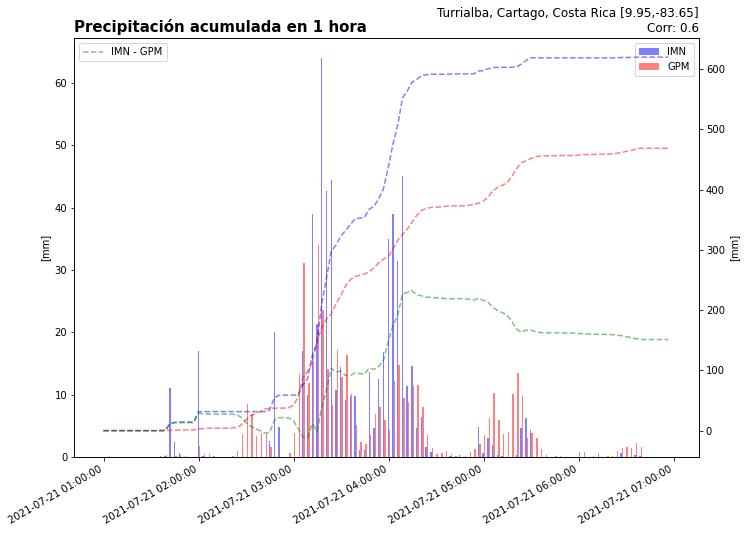

In [44]:
#Obtenemos la posicion de cada etiqueta en el eje de X
x = np.arange(len(TURR_1H['TURR_IMN']))
#tamaño de cada barra
width = 0.3

fig, ax = plt.subplots(figsize = (10,8))

#Generamos las barras para el conjunto de IMN
rects1 = ax.bar(x - width/2, TURR_1H['TURR_IMN'],width,label='IMN',color= 'blue',alpha=0.5)
rects2 = ax.bar(x + width/2, TURR_1H['TURR_GPM_ST'], width, label='GPM',color= 'red',alpha=0.5)

twin_axes = ax.twinx() 
twin_axes.plot(x - width/2, np.cumsum(TURR_1H['TURR_IMN']),color= 'blue', linestyle='--', alpha=0.5)
twin_axes.plot(x - width/2, np.cumsum(TURR_1H['TURR_GPM_ST']),color= 'red',linestyle='--',alpha=0.5)
twin_axes.plot(x - width/2, (np.cumsum(TURR_1H['TURR_IMN']) - np.cumsum(TURR_1H['TURR_GPM_ST'])), label='IMN - GPM', color= 'green',linestyle='--',alpha=0.5)
twin_axes.set_ylabel('[mm]')
twin_axes.legend()


#Añadimos las etiquetas de identificacion de valores en el grafico
ax.set_ylabel('[mm]')
ax.set_title('Precipitación acumulada en 1 hora', fontweight='bold', fontsize=15, loc='left')
ax.set_title('Turrialba, Cartago, Costa Rica [9.95,-83.65]\nCorr: 0.6', fontsize=12, loc='right')
#ax.set_xticks(x)
ax.set_xticklabels(TURR_1H['TURR_IMN'].index)

ax.legend()
fig.tight_layout()
fig.autofmt_xdate()
plt.show()

/var/folders/v8/b0fnjf9d4q31sfz_8q4h4zxm0000gn/T/ipykernel_17380/1509931254.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(TURR_IMN_6.index)


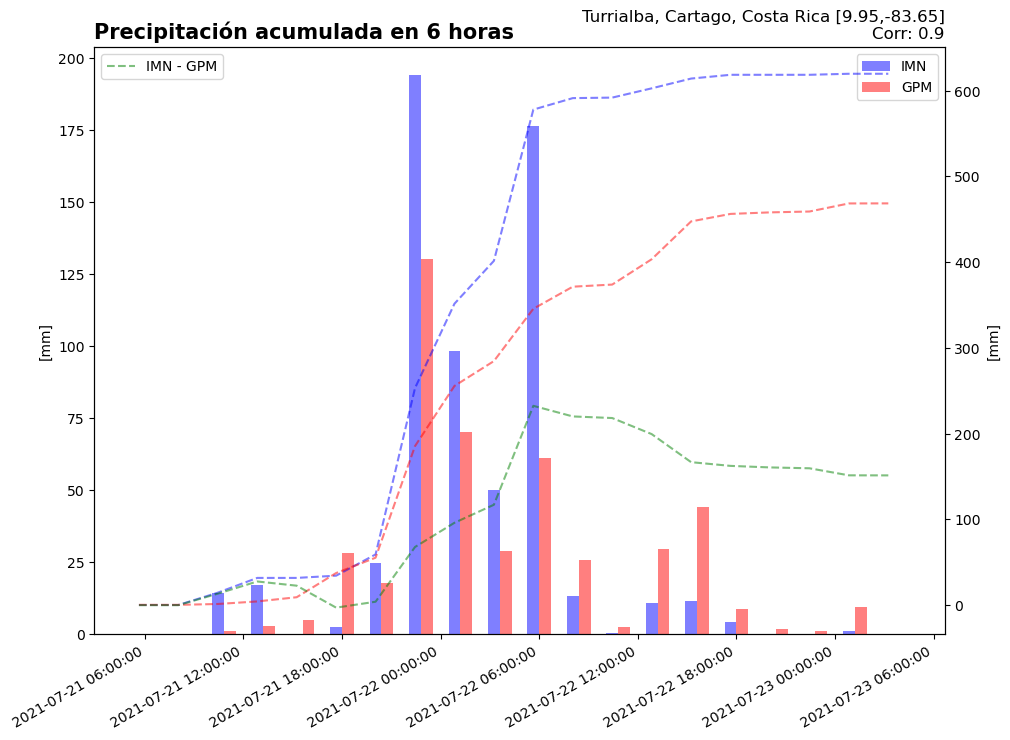

In [5]:
#Obtenemos la posicion de cada etiqueta en el eje de X
x = np.arange(len(TURR_IMN_6))
#tamaño de cada barra
width = 0.3

fig, ax = plt.subplots(figsize = (10,8))

#Generamos las barras para el conjunto de IMN
rects1 = ax.bar(x - width/2, TURR_IMN_6,width,label='IMN',color= 'blue',alpha=0.5)
rects2 = ax.bar(x + width/2, TURR_GPM_6, width, label='GPM',color= 'red',alpha=0.5)

twin_axes = ax.twinx() 
twin_axes.plot(x - width/2, np.cumsum(TURR_IMN_6),color= 'blue', linestyle='--', alpha=0.5)
twin_axes.plot(x - width/2, np.cumsum(TURR_GPM_6),color= 'red',linestyle='--',alpha=0.5)
twin_axes.plot(x - width/2, (np.cumsum(TURR_IMN_6) - np.cumsum(TURR_GPM_6)), label='IMN - GPM', color= 'green',linestyle='--',alpha=0.5)
twin_axes.set_ylabel('[mm]')
twin_axes.legend()


#Añadimos las etiquetas de identificacion de valores en el grafico
ax.set_ylabel('[mm]')
ax.set_title('Precipitación acumulada en 6 horas', fontweight='bold', fontsize=15, loc='left')
ax.set_title('Turrialba, Cartago, Costa Rica [9.95,-83.65]\nCorr: 0.9', fontsize=12, loc='right')
#ax.set_xticks(x)
ax.set_xticklabels(TURR_IMN_6.index)

ax.legend()
fig.tight_layout()
fig.autofmt_xdate()
plt.show()

In [7]:
print(np.cumsum(TURR_IMN_6))
print(np.cumsum(TURR_GPM_6))
print(np.cumsum(TURR_GPM_1) - np.cumsum(TURR_GPM_1))

Date
2021-07-21 00:00:00      0.0
2021-07-21 06:00:00      0.0
2021-07-21 12:00:00     14.4
2021-07-21 18:00:00     31.6
2021-07-22 00:00:00     31.6
2021-07-22 06:00:00     34.2
2021-07-22 12:00:00     59.0
2021-07-22 18:00:00    253.0
2021-07-23 00:00:00    351.4
2021-07-23 06:00:00    401.4
2021-07-23 12:00:00    577.8
2021-07-23 18:00:00    591.2
2021-07-24 00:00:00    591.8
2021-07-24 06:00:00    602.6
2021-07-24 12:00:00    614.0
2021-07-24 18:00:00    618.4
2021-07-25 00:00:00    618.4
2021-07-25 06:00:00    618.4
2021-07-25 12:00:00    619.6
2021-07-25 18:00:00    619.6
Freq: 6H, Name: pcp, dtype: float64
Date
2021-07-21 00:00:00      0.169686
2021-07-21 06:00:00      0.174914
2021-07-21 12:00:00      1.174921
2021-07-21 18:00:00      4.159649
2021-07-22 00:00:00      9.066772
2021-07-22 06:00:00     37.285498
2021-07-22 12:00:00     55.169166
2021-07-22 18:00:00    185.339751
2021-07-23 00:00:00    255.501365
2021-07-23 06:00:00    284.474721
2021-07-23 12:00:00    345.499012


# Middle Term - Turrialba, Cartago

In [8]:
#Lectura de datos

Data = pd.read_csv('/Users/maureenfonseca/Desktop/UCR/UNIFICADO.csv', sep=',')

In [9]:
#Indexando los datos con la fecha
Data['Date'] = pd.to_datetime(Data['Date'],infer_datetime_format=True)
Data.index = Data['Date']

In [10]:
#Extracción de datos
TURR_IMN2 = Data['TURR_IMN'].loc['2019-09-01 00:00:00':'2019-09-30 23:55:00']
TURR_GPM2 = Data['TURR_GPM'].loc['2019-09-01 00:00:00':'2019-09-30 23:55:00']

In [17]:
#Creando listas de los acumulados de precipitación
TURR_IMN_6 = TURR_IMN2.resample('6H').sum()
TURR_GPM_6 = TURR_GPM2.resample('6H').sum()
corr_6 = np.corrcoef(TURR_IMN_6, TURR_GPM_6)
print(corr_6)

TURR_IMN_24 = TURR_IMN2.resample('24H').sum()
TURR_GPM_24 = TURR_GPM2.resample('24H').sum()
corr_24 = np.corrcoef(TURR_IMN_24, TURR_GPM_24)
print(corr_24)

[[1.         0.80545495]
 [0.80545495 1.        ]]
[[1.         0.82823033]
 [0.82823033 1.        ]]


In [18]:
np.cumsum(TURR_IMN_6)-np.cumsum(TURR_GPM_6)

Date
2019-09-01 00:00:00    -0.136443
2019-09-01 06:00:00    -0.250671
2019-09-01 12:00:00    -0.250671
2019-09-01 18:00:00    -3.645663
2019-09-02 00:00:00    -3.645663
                         ...    
2019-09-29 18:00:00   -69.581282
2019-09-30 00:00:00   -73.467647
2019-09-30 06:00:00   -73.467939
2019-09-30 12:00:00   -77.535641
2019-09-30 18:00:00   -78.878645
Freq: 6H, Length: 120, dtype: float64

### Acumulado de 6 Horas

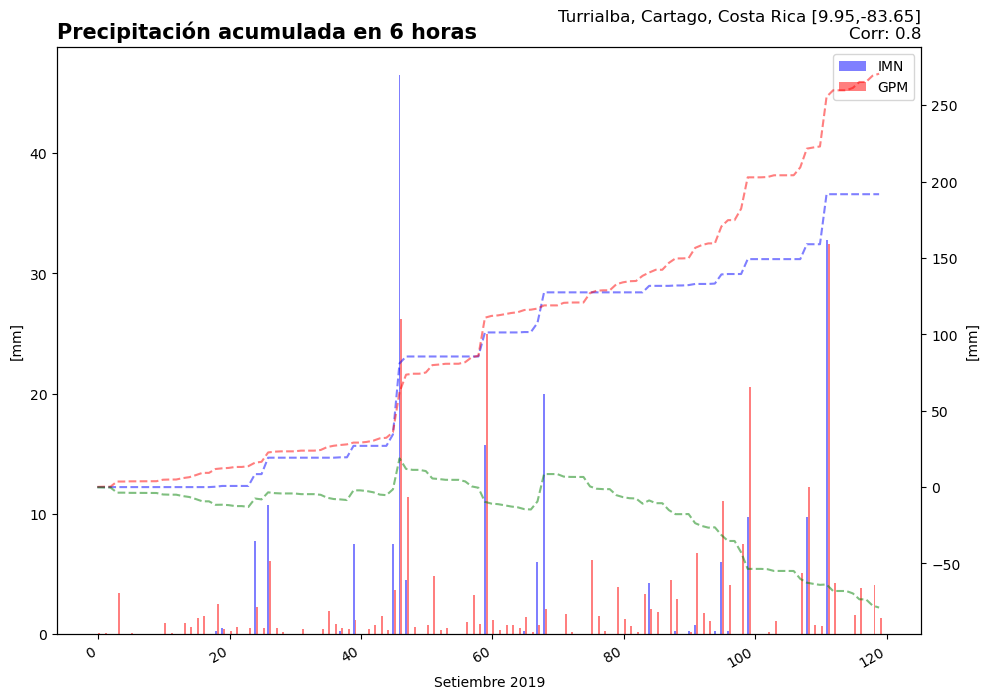

In [13]:
#Obtenemos la posicion de cada etiqueta en el eje de X
x = np.arange(len(TURR_IMN_6))
#tamaño de cada barra
width = 0.3

fig, ax = plt.subplots(figsize = (10,8))

#Generamos las barras para el conjunto de IMN
rects1 = ax.bar(x - width/2, TURR_IMN_6,width,label='IMN',color= 'blue',alpha=0.5)
rects2 = ax.bar(x + width/2, TURR_GPM_6, width, label='GPM',color= 'red',alpha=0.5)

twin_axes = ax.twinx() 
twin_axes.plot(x - width/2, np.cumsum(TURR_IMN_6),color= 'blue', linestyle='--', alpha=0.5)
twin_axes.plot(x - width/2, np.cumsum(TURR_GPM_6),color= 'red',linestyle='--',alpha=0.5)
twin_axes.plot(x - width/2, (np.cumsum(TURR_IMN_6) - np.cumsum(TURR_GPM_6)), label='IMN - GPM', color= 'green',linestyle='--',alpha=0.5)
twin_axes.set_ylabel('[mm]')


#Añadimos las etiquetas de identificacion de valores en el grafico
ax.set_ylabel('[mm]')
ax.set_xlabel('Setiembre 2019')
ax.set_title('Precipitación acumulada en 6 horas', fontweight='bold', fontsize=15, loc='left')
ax.set_title('Turrialba, Cartago, Costa Rica [9.95,-83.65]\nCorr: 0.8', fontsize=12, loc='right')
#ax.set_xticks(x)
#ax.set_xticklabels(x+1)

ax.legend()
fig.tight_layout()
fig.autofmt_xdate()
plt.show()

### Acumulado de 24 horas

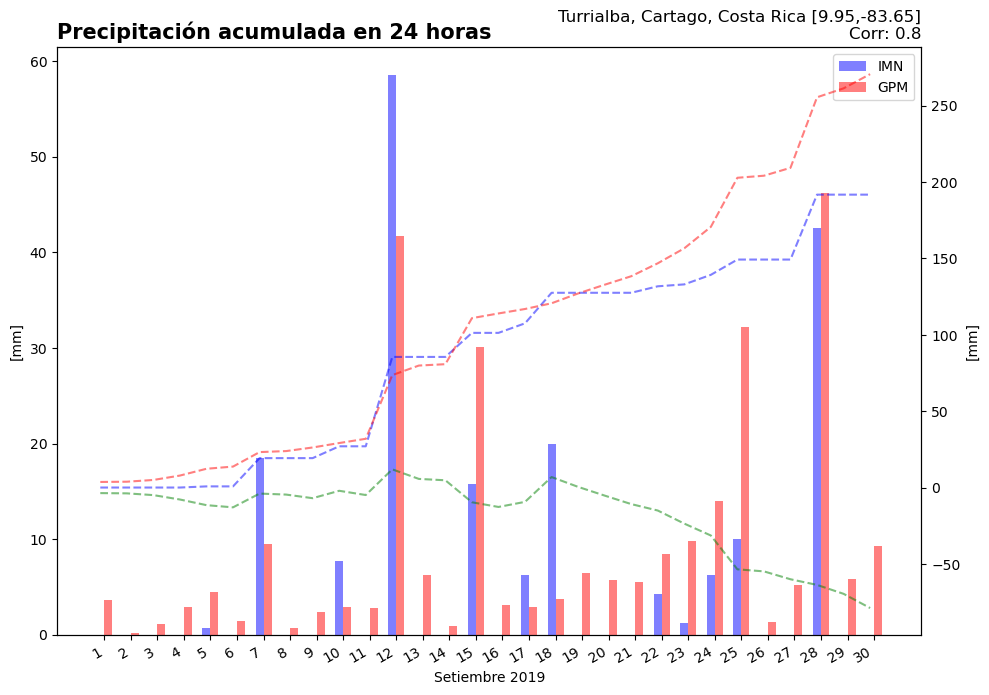

In [14]:
#Obtenemos la posicion de cada etiqueta en el eje de X
x = np.arange(len(TURR_IMN_24))
#tamaño de cada barra
width = 0.3

fig, ax = plt.subplots(figsize = (10,8))

#Generamos las barras para el conjunto de IMN
rects1 = ax.bar(x - width/2, TURR_IMN_24,width,label='IMN',color= 'blue',alpha=0.5)
rects2 = ax.bar(x + width/2, TURR_GPM_24, width, label='GPM',color= 'red',alpha=0.5)

twin_axes = ax.twinx() 
twin_axes.plot(x - width/2, np.cumsum(TURR_IMN_24),color= 'blue', linestyle='--', alpha=0.5)
twin_axes.plot(x - width/2, np.cumsum(TURR_GPM_24),color= 'red',linestyle='--',alpha=0.5)
twin_axes.plot(x - width/2, (np.cumsum(TURR_IMN_24) - np.cumsum(TURR_GPM_24)), label='IMN - GPM', color= 'green',linestyle='--',alpha=0.5)
twin_axes.set_ylabel('[mm]')


#Añadimos las etiquetas de identificacion de valores en el grafico
ax.set_ylabel('[mm]')
ax.set_xlabel('Setiembre 2019')
ax.set_title('Precipitación acumulada en 24 horas', fontweight='bold', fontsize=15, loc='left')
ax.set_title('Turrialba, Cartago, Costa Rica [9.95,-83.65]\nCorr: 0.8', fontsize=12, loc='right')
ax.set_xticks(x)
ax.set_xticklabels(x+1)

ax.legend()
fig.tight_layout()
fig.autofmt_xdate()
plt.show()

# Long Term - Santa Cruz, Guanacaste

In [2]:
#Lectura de datos

STCZ_IMN = pd.read_csv('/Users/maureenfonseca/Desktop/UCR/STCZ_LP_AWS.csv', sep=';')
STCZ_GPM = pd.read_csv('/Users/maureenfonseca/Desktop/UCR/STCZ_LP_GPM.csv', sep=',')

In [3]:
#Creando vector de fechas
min_date = "2000-06-01"
max_date = "2021-10-01"
dates = pd.period_range(min_date, max_date, freq='30min')
Dates = dates[:-1]

In [4]:
Dates

PeriodIndex(['2000-06-01 00:00', '2000-06-01 00:30', '2000-06-01 01:00',
             '2000-06-01 01:30', '2000-06-01 02:00', '2000-06-01 02:30',
             '2000-06-01 03:00', '2000-06-01 03:30', '2000-06-01 04:00',
             '2000-06-01 04:30',
             ...
             '2021-09-30 19:00', '2021-09-30 19:30', '2021-09-30 20:00',
             '2021-09-30 20:30', '2021-09-30 21:00', '2021-09-30 21:30',
             '2021-09-30 22:00', '2021-09-30 22:30', '2021-09-30 23:00',
             '2021-09-30 23:30'],
            dtype='period[30T]', length=374016)

In [5]:
#Asignando el vector de fechas al dataframe del GPM
STCZ_GPM['Date'] = Dates

In [6]:
STCZ_GPM[150:155]

,time,GPM,Date
150,00:00,0.000000,2000-06-04 03:00
151,30:00,0.000000,2000-06-04 03:30
152,2000-06-04 04:00:00,0.011928,2000-06-04 04:00
153,2000-06-04 04:30:00,0.002257,2000-06-04 04:30
154,00:00,0.000000,2000-06-04 05:00


In [7]:
#Cambiando el formato de fecha del dataframe del IMN
Date = []
for i in range(len(STCZ_IMN.Cuenca)):
    date = str(STCZ_IMN.Fecha[i])+' '+str(STCZ_IMN.Hora[i])
    Date.append(date)

In [8]:
STCZ_IMN['Date']= Date

In [9]:
STCZ_IMN[150:155]

,Cuenca,Estaci�n,Fecha,Hora,Lluvia (mm),Date
150,74,53,7/6/00,06:00,0.0,7/6/00 06:00
151,74,53,7/6/00,07:00,0.0,7/6/00 07:00
152,74,53,7/6/00,08:00,0.0,7/6/00 08:00
153,74,53,7/6/00,09:00,0.0,7/6/00 09:00
154,74,53,7/6/00,10:00,0.0,7/6/00 10:00


In [10]:
#Indexando los datos con la fecha
STCZ_IMN['Date'] = pd.to_datetime(STCZ_IMN['Date'],infer_datetime_format=True)
STCZ_IMN.index = STCZ_IMN['Date']

STCZ_GPM['Date'] = STCZ_GPM['Date'].dt.to_timestamp('s').dt.strftime('%Y-%m-%d %H:%M:%S')
STCZ_GPM['Date'] = pd.to_datetime(STCZ_GPM['Date'],infer_datetime_format=True)
STCZ_GPM.index = STCZ_GPM['Date']

In [11]:
#Cambiando la resolución temporal del GPM
STCZ_GPM = STCZ_GPM.resample('1H').sum()

/var/folders/v8/b0fnjf9d4q31sfz_8q4h4zxm0000gn/T/ipykernel_39628/3774187611.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  STCZ_GPM = STCZ_GPM.resample('1H').sum()


In [12]:
#Configurando las listas 
W_STCZ_IMN  = np.hamming(len(STCZ_IMN['Lluvia (mm)'].values))

FT_pcp_IMN = np.fft.fft(W_STCZ_IMN * (STCZ_IMN['Lluvia (mm)'] - STCZ_IMN['Lluvia (mm)'].mean()))
XFT_pcp_IMN = np.fft.fftfreq(len(FT_pcp_IMN),d=3600)

W_STCZ_GPM  = np.hamming(len(STCZ_GPM['GPM'].values))

FT_pcp_GPM = np.fft.fft(W_STCZ_GPM[0:1] * (STCZ_GPM['GPM'] - STCZ_GPM['GPM'].mean()))
XFT_pcp_GPM = np.fft.fftfreq(len(FT_pcp_GPM),d=3600)

### Graficación

**Espectro de Frecuencia**

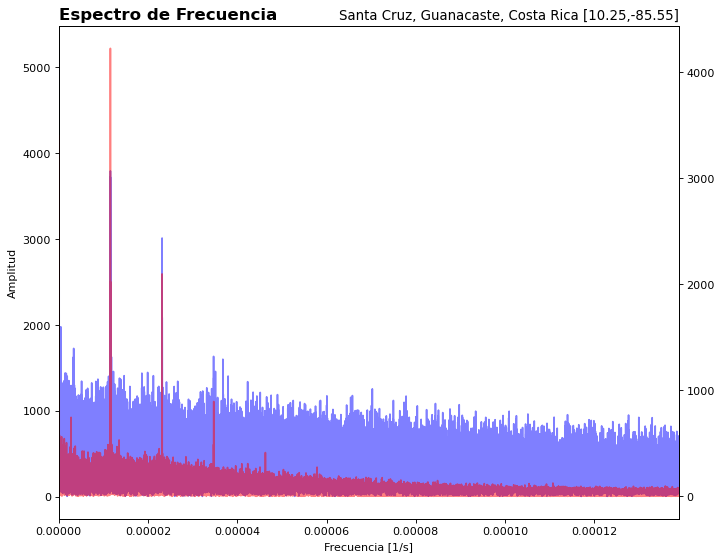

In [26]:
fig = plt.figure(figsize=(10,8), dpi=80)
ax1 = fig.add_subplot(111)

ax1.plot(XFT_pcp_IMN, np.abs(FT_pcp_IMN),color= 'blue', alpha=0.5, label='IMN')
ax1.set_ylabel('Amplitud')
ax1.set_xlabel('Frecuencia [1/s]')
ax1.set_xlim(0, np.max(XFT_pcp_IMN))
ax1.set_title('Espectro de Frecuencia', fontweight='bold', fontsize=15, loc='left')
ax1.set_title('Santa Cruz, Guanacaste, Costa Rica [10.25,-85.55]', fontsize=12, loc='right')

ax2 = ax1.twinx()
ax2.plot(XFT_pcp_GPM, np.abs(FT_pcp_GPM),color= 'red', alpha=0.5, label='GPM')
#ax1.legend()
#ax2.legend()

**Serie de Tiempo**

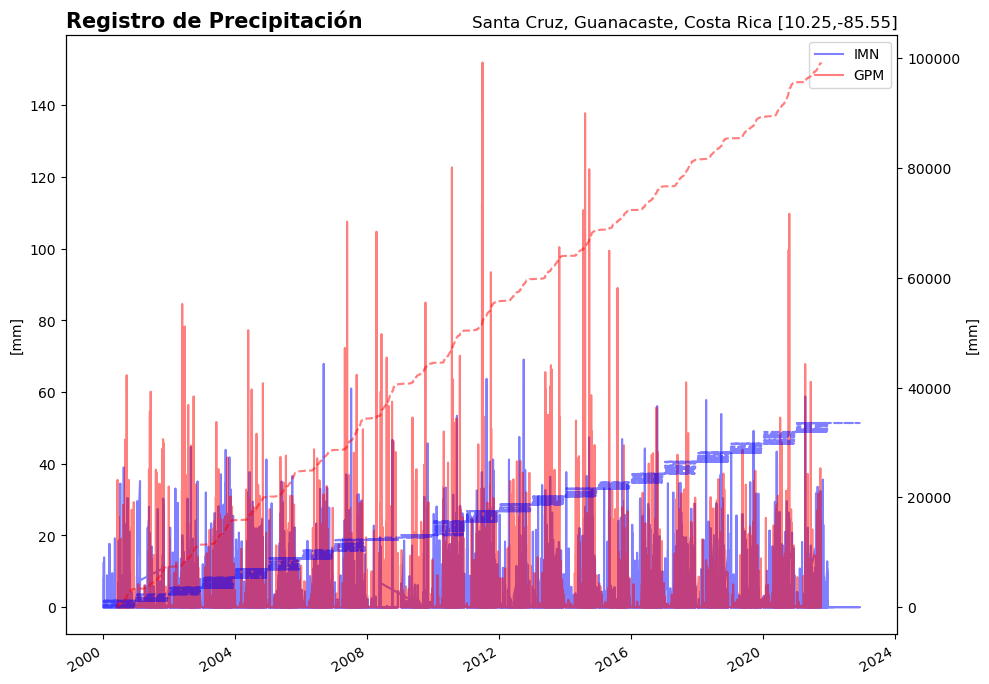

In [22]:
fig, ax = plt.subplots(figsize = (10,8))

#Generamos las barras para el conjunto de GPM
rects1 = ax.plot(STCZ_IMN['Lluvia (mm)'],label='IMN',color= 'blue',alpha=0.5)
rects2 = ax.plot(STCZ_GPM['GPM'],label='GPM',color= 'red',alpha=0.5)

twin_axes = ax.twinx() 
twin_axes.plot(np.cumsum(STCZ_IMN['Lluvia (mm)']),color= 'blue', linestyle='--', alpha=0.5)
twin_axes.plot(np.cumsum(STCZ_GPM['GPM']),color= 'red',linestyle='--',alpha=0.5)
twin_axes.set_ylabel('[mm]')


#Añadimos las etiquetas de identificacion de valores en el grafico
ax.set_ylabel('[mm]')
ax.set_xlabel('')
ax.set_title('Registro de Precipitación', fontweight='bold', fontsize=15, loc='left')
ax.set_title('Santa Cruz, Guanacaste, Costa Rica [10.25,-85.55]', fontsize=12, loc='right')

ax.legend()
fig.tight_layout()
fig.autofmt_xdate()
plt.show()

In [15]:
np.cumsum(STCZ_GPM['GPM'])

Date
2000-06-01 00:00:00       10.730490
2000-06-01 01:00:00       15.803096
2000-06-01 02:00:00       21.557597
2000-06-01 03:00:00       25.727345
2000-06-01 04:00:00       27.246390
                           ...     
2021-09-30 19:00:00    99188.183826
2021-09-30 20:00:00    99197.530712
2021-09-30 21:00:00    99214.385776
2021-09-30 22:00:00    99230.509580
2021-09-30 23:00:00    99246.448253
Freq: H, Name: GPM, Length: 187008, dtype: float64

In [18]:
np.cumsum(STCZ_IMN['Lluvia (mm)'])

Date
2000-01-06 00:00:00        0.0
2000-01-06 01:00:00        0.1
2000-01-06 02:00:00        0.1
2000-01-06 03:00:00        0.1
2000-01-06 04:00:00        0.1
                        ...   
2022-02-14 05:00:00    33555.9
2022-02-14 06:00:00    33555.9
2022-02-14 07:00:00    33555.9
2022-02-14 08:00:00    33555.9
2022-02-14 09:00:00    33555.9
Name: Lluvia (mm), Length: 173424, dtype: float64

In [21]:
100-((len(STCZ_IMN)*100)/len(STCZ_GPM))

7.2638603696098585